# Testing TPS and Alternatives

In [1]:
import os
import kornia as K
import numpy as np
import torch
import matplotlib.pyplot as plt
import math 
import skimage as ski

from utils import convert_image_to_tensor, match_sizes_resize, group_by_argmax
from DatasetTools.LeafImageSeries import LeafDataset
from masking import fetch_image_mask_pair
from loftr import loftr_match, warp_tps, tps_skimage, tps_skimage_confidence, filter_matches_by_grid, filter_matches_by_cluster, filter_matches_by_min_distance
from registration import fetch_registered_image_mask_seq
from plotting import plot_image_series, plot_image_pair, plot_overlay, plot_match_coverage

In [2]:
leaf = LeafDataset(
    base_dir='../leaf-image-sequences',
    # leaf_uid="ESWW0070020_2",
    leaf_uid="ESWW0070040_6", # has much missing data 
    load=('roi_leaf_masks'),
    # load=('target_images', 'target_masks', 'leaf_masks', 'seg_masks', 'det_masks', 'cropped_images', 'rois', 'images', 'keypoints', 'roi_leaf_masks'),
    verbose=False
)

Processing series: 100%|██████████| 17/17 [00:05<00:00,  3.22it/s]


Total matches: 1079
Matches with Confidence > 0.5: 387
Inliers: 206 (19.09%)


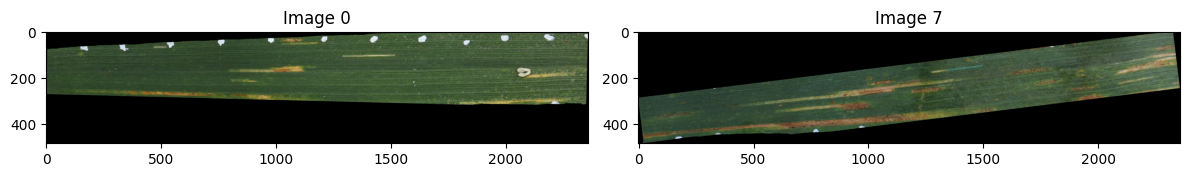

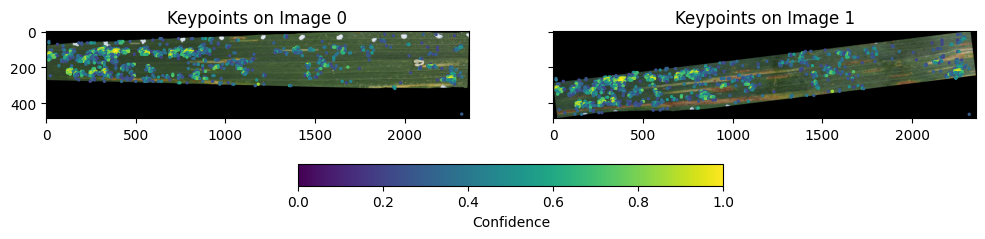

In [24]:
fix_ind = 0
# mov_ind = 2 # easy example
mov_ind = 7 # hard example
img_fixed, mask_fixed = fetch_image_mask_pair(leaf, fix_ind, img_scale="roi")
img_moving, mask_moving = fetch_image_mask_pair(leaf, mov_ind, img_scale="roi")
img_fixed, img_moving, mask_fixed, mask_moving = match_sizes_resize(img_fixed, img_moving, mask_fixed, mask_moving)
_ = plot_image_pair(img_fixed, img_moving, fix_ind, mov_ind)
# get loftr matches
mkpts0, mkpts1, confidence, inliers, n_matches = loftr_match(img_fixed, img_moving, verbose=True, return_n_matches=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence)

Total matches: 4697
Matches with Confidence > 0.5: 2992
Inliers: 2845 (60.57%)


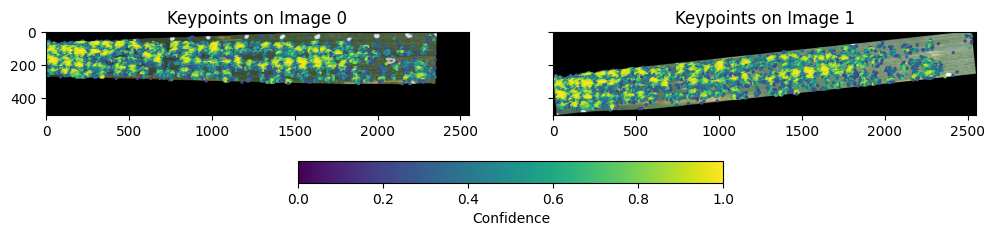

In [19]:
# get loftr matches
mkpts0, mkpts1, confidence, inliers, n_matches = loftr_match(img_fixed, img_moving, verbose=True, return_n_matches=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence)

## Skimage TPS

Threshold set to 0.5
Estimating TPS transform...
Transforming moving image...


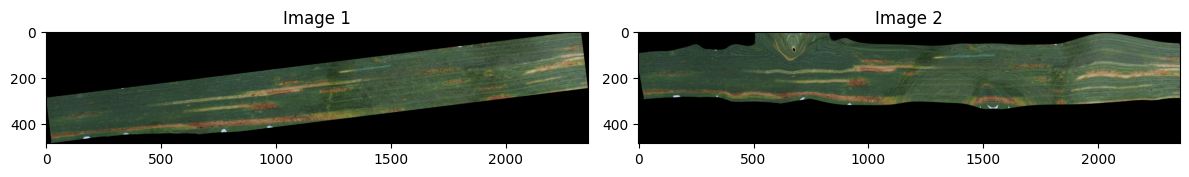

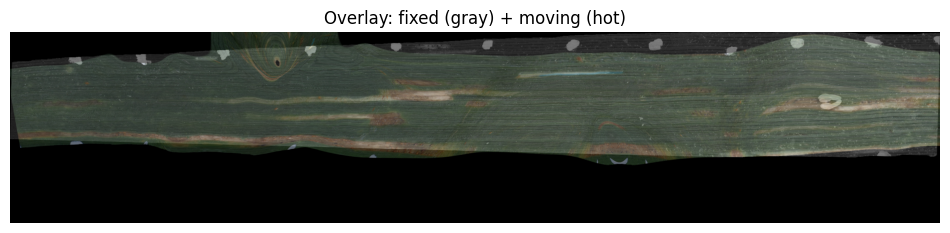

In [79]:
threshold = 0.5
out_og, _ = tps_skimage_confidence(mkpts0, mkpts1, confidence, threshold, img_moving, verbose=True)
_=plot_image_pair(img_moving, out_og)
_=plot_overlay(img_fixed, out_og)

## Torch-TPS

In [1]:
def increase_ctrl_points():
    """Generate ctrl points that increase the center of the image.

    (In proportion of the desired shapes)
    """
    input_ctrl = torch.tensor(
        [
            [0.25, 0.25],  # (i_0, j_0)
            [0.25, 0.75],  # (i_0, j_1)
            [0.75, 0.25],  # (i_1, j_0)
            [0.75, 0.75],  # (i_1, j_1)
        ]
    )

    output_ctrl = torch.tensor(
        [
            [0.15, 0.15],
            [0.15, 0.85],
            [0.85, 0.15],
            [0.85, 0.85],
        ]
    )

    corners = torch.tensor(  # Add corners ctrl points
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
            [1.0, 1.0],
        ]
    )

    return torch.cat((input_ctrl, corners)), torch.cat((output_ctrl, corners))

In [86]:
from torch_tps import ThinPlateSpline
def torch_tps(target_keypts, moving_keypts, moving_img, alpha=0.5):
    """
    keypoints have format (x,y)
    """
    image = convert_image_to_tensor(moving_img)
    height = image.shape[2]
    width = image.shape[3]
    size = torch.tensor((height, width))

    target_keypts = target_keypts[..., [1, 0]] # meshgrid builder expects (y,x) format
    moving_keypts = moving_keypts[..., [1, 0]]

    # Fit the thin plate spline from output to input
    tps = ThinPlateSpline(alpha)
    tps.fit(target_keypts, moving_keypts)

    # Create the 2d meshgrid of indices for output image
    i = torch.arange(height, dtype=torch.float32)
    j = torch.arange(width, dtype=torch.float32)

    ii, jj = torch.meshgrid(i, j, indexing="ij")
    output_indices = torch.cat((ii[..., None], jj[..., None]), dim=-1)  # Shape (H, W, 2)

    # Transform it into the input indices
    input_indices = tps.transform(output_indices.reshape(-1, 2)).reshape(height, width, 2)

    # Interpolate the resulting image
    grid = 2 * input_indices / size - 1  # Into [-1, 1]
    grid = torch.flip(grid, (-1,))  # Grid sample works with x,y coordinates, not i, j
    warped = torch.nn.functional.grid_sample(image, grid[None, ...], align_corners=False)[0]

    return warped


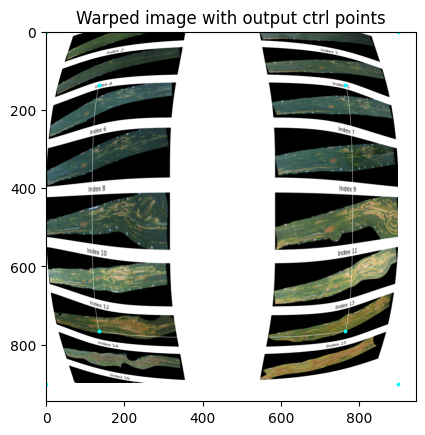

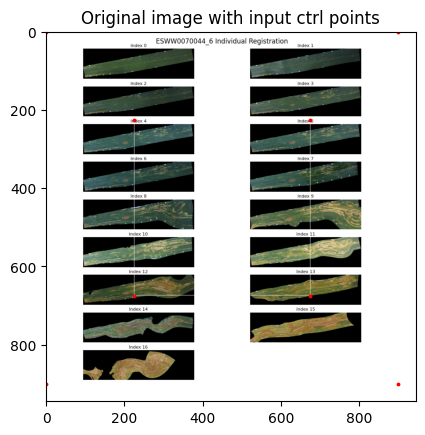

In [87]:
from PIL import Image, ImageDraw 
image = Image.open("temp/ESWW0070044_6_individual.png").convert("RGB")
width, height = image.size
ImageDraw.Draw(image).rectangle([width * 0.25, height * 0.25, width * 0.75, height * 0.75])

size = torch.tensor((height, width))
# Build control points
input_ctrl, output_ctrl = increase_ctrl_points()
input_ctrl *= size # input <=> coords of landmarks in original moving image
output_ctrl *= size # output <=> target coords, i.e. coords of landmarks in warped image

warped = torch_tps(output_ctrl, input_ctrl, image)


plt.figure()
plt.imshow(K.tensor_to_image(warped))
plt.scatter(output_ctrl[:,1], output_ctrl[:,0], color='cyan', s=3, label="output")
plt.title("Warped image with output ctrl points")

plt.figure()
plt.imshow(image)
plt.scatter(input_ctrl[:,1], input_ctrl[:,0], color='red', s=3, label="input")
plt.title("Original image with input ctrl points")

plt.show()

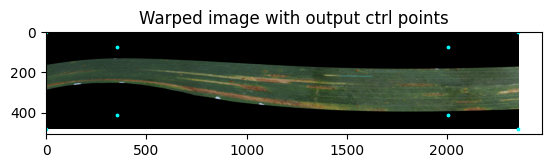

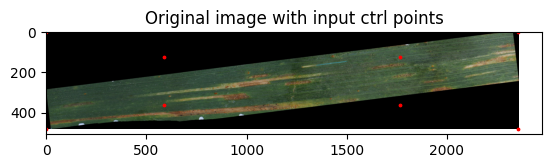

In [88]:
height = img_moving.shape[2]
width = img_moving.shape[3]
size = torch.tensor((height, width))

# Build control points
input_ctrl, output_ctrl = increase_ctrl_points()
input_ctrl *= size # input <=> coords of landmarks in original moving image
output_ctrl *= size # output <=> target coords, i.e. coords of landmarks in warped image

warped = torch_tps(output_ctrl, input_ctrl, img_moving)


plt.figure()
plt.imshow(K.tensor_to_image(warped))
plt.scatter(output_ctrl[:,1], output_ctrl[:,0], color='cyan', s=3, label="output")
plt.title("Warped image with output ctrl points")

plt.figure()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(input_ctrl[:,1], input_ctrl[:,0], color='red', s=3, label="input")
plt.title("Original image with input ctrl points")

plt.show()

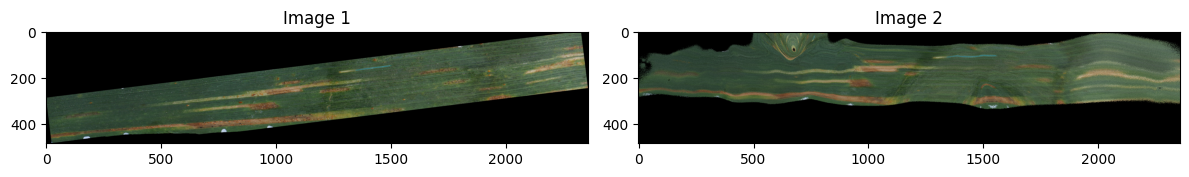

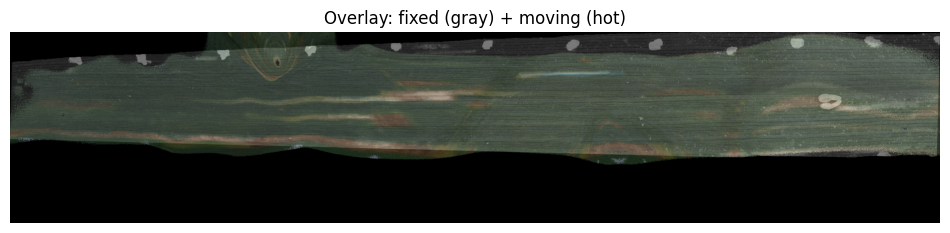

In [89]:
# Control points
# threshold = 0.95705032704
threshold = 0.5
moving_keypts = mkpts1[confidence > threshold] # coordinates in (x,y) format
target_keypts = mkpts0[confidence > threshold]

out = torch_tps(target_keypts, moving_keypts, img_moving, alpha=0.9)

# plotting result
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

### With Filtered Landmarks

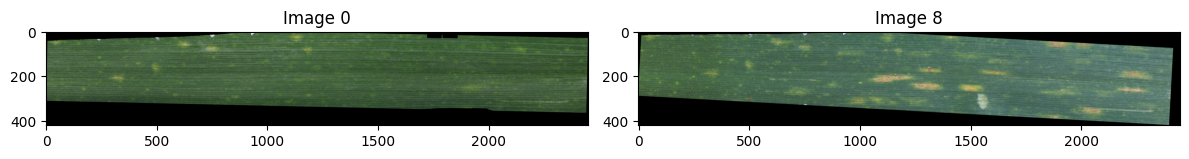

In [ ]:
leaf2 = LeafDataset(
    base_dir='../leaf-image-sequences',
    leaf_uid="ESWW0070020_1",
    # leaf_uid="ESWW0070023_6", # has much missing data 
    load=('roi_leaf_masks'),
    # load=('target_images', 'target_masks', 'leaf_masks', 'seg_masks', 'det_masks', 'cropped_images', 'rois', 'images', 'keypoints', 'roi_leaf_masks'),
    verbose=False
)

ind = 8
img_fixed, mask_fixed = fetch_image_mask_pair(leaf2, 0, img_scale="roi")
img_moving, mask_moving = fetch_image_mask_pair(leaf2, ind, img_scale="roi")
img_fixed, img_moving, mask_fixed, mask_moving = match_sizes_resize(img_fixed, img_moving, mask_fixed, mask_moving)
_ = plot_image_pair(img_fixed, img_moving, 0, ind)

Total matches: 4984
Matches with Confidence > 0.5: 3009
Inliers: 1141 (22.89%)


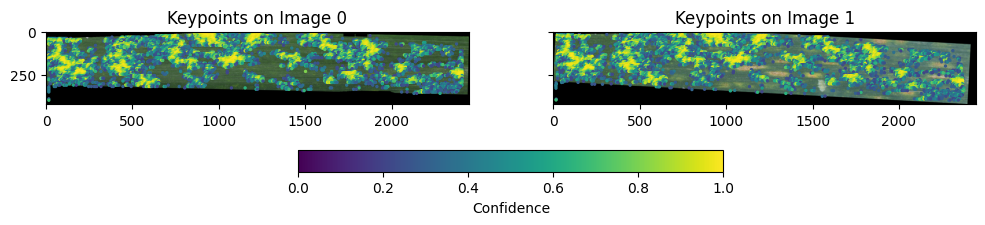

In [98]:
# get loftr matches
mkpts0, mkpts1, confidence, inliers, n_matches = loftr_match(img_fixed, img_moving, verbose=True, return_n_matches=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence)

Number of Matches: 277


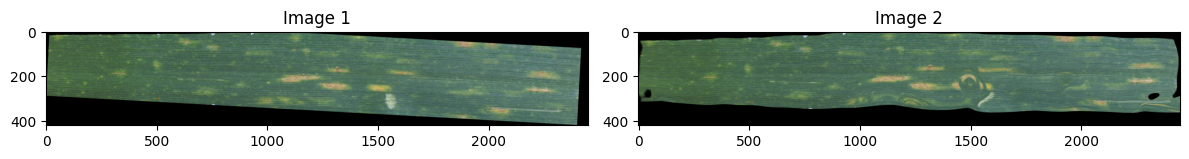

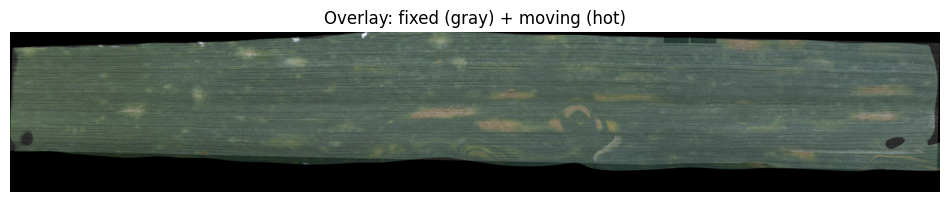

In [101]:
from loftr import filter_matches_by_grid

cell_size=50
threshold=0.5
alpha = 0.9
cell_matches_fix, cell_matches_mov = filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width=img_fixed.shape[3], cell_size=cell_size, threshold=threshold)
print(f"Number of Matches: {cell_matches_fix.shape[0]}")
out = torch_tps(cell_matches_fix, cell_matches_mov, img_moving, alpha)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

## RBF Interpolation

In [ ]:
from scipy.interpolate import RBFInterpolator
from scipy.ndimage import map_coordinates
def tps_scipy(target_keypts, moving_keypts, moving_image, smoothing=1e-3):
    if type(moving_image) != torch.Tensor:
        moving_image = convert_image_to_tensor(moving_image)
    H, W = moving_image.shape[2:]

    # compute displacements
    displacements = moving_keypts - target_keypts

    # build interpolator
    rbf = RBFInterpolator(
        src_pts,
        displacements,
        kernel="thin_plate_spline",
        smoothing=smoothing   # start small
    )    

    # create grid of pixel coordinates
    grid_y, grid_x = np.meshgrid(
        np.arange(H),
        np.arange(W),
        indexing="ij"
    )

    coords = np.column_stack([grid_x.ravel(), grid_y.ravel()])

    # evaluate displacement for each pixel coordinate
    disp = rbf(coords)
    new_coords = coords + disp

    map_x = new_coords[:, 0].reshape(H, W)
    map_y = new_coords[:, 1].reshape(H, W)

    # coords = np.stack([map_y, map_x])  # shape (2, H, W)

    # # warp each channel individually
    # image = K.tensor_to_image(moving_image)
    # warped = np.zeros_like(image)
    # for c in range(image.shape[2]):
    #     warped[..., c] = map_coordinates(
    #         image[..., c],
    #         coords,
    #         order=1,
    #     )


    grid_x = 2.0 * map_x / (W - 1) - 1.0
    grid_y = 2.0 * map_y / (H - 1) - 1.0

    grid = np.stack([grid_x, grid_y], axis=-1)  # (H, W, 2)
    grid = torch.from_numpy(grid).float().unsqueeze(0)  # (1, H, W, 2)

    warped = torch.nn.functional.grid_sample(
        moving_image,
        grid,
        mode="bilinear",
        align_corners=True
    )

    return warped

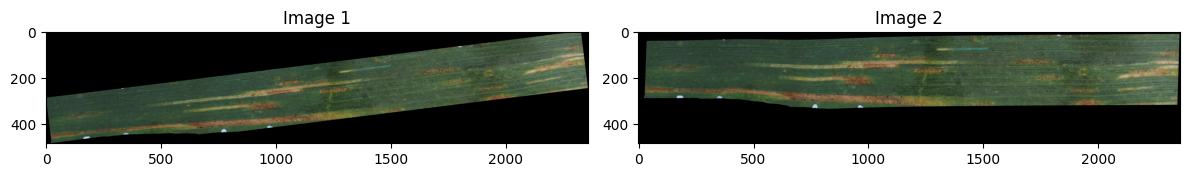

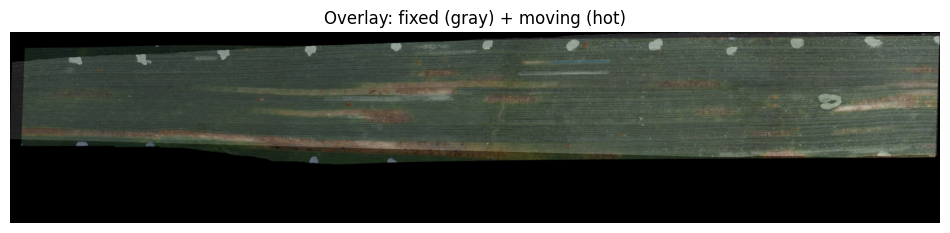

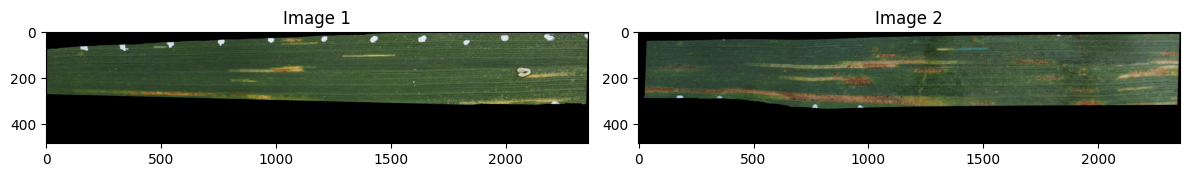

In [43]:
from scipy.interpolate import RBFInterpolator
from scipy.ndimage import map_coordinates
# Nx2 arrays
# threshold = 0.5
threshold = 0.96
src_pts = mkpts1[confidence > threshold] # source landmark coordinates
dst_pts = mkpts0[confidence > threshold]  # matching destination landmarks

out = tps_scipy(dst_pts, src_pts, img_moving, smoothing=0)

_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)
_=plot_image_pair(img_fixed, out)

## B-Spline Free Form Deformation